## Random Forest Classification on PneumoniaMNIST

High-Level Dataset Overview — PneumoniaMNIST
What it is: A binary image classification dataset derived from pediatric chest X-rays.

Task: Classify images as:

0 = Normal
1 = Pneumonia
Size:

Train: 4,708
Validation: 524
Test: 624
Total 5,856 images.
Image format:

Gray-scale
28×28 pixels (MNIST-like)
No clinical preprocessing required.

This dataset is ideal for demonstrating how classic machine learning methods (like Random Forest).

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from medmnist import PneumoniaMNIST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 2: Let's load the dataset

In [23]:
train_ds = PneumoniaMNIST(split='train', download=True)
val_ds   = PneumoniaMNIST(split='val', download=True)
test_ds  = PneumoniaMNIST(split='test', download=True)

In [24]:
train_ds.info

{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

### Visualize Examples

In [25]:
train_ds[0]

(<PIL.Image.Image image mode=L size=28x28>, array([1]))

In [26]:
#example visual
train_ds[0][0]

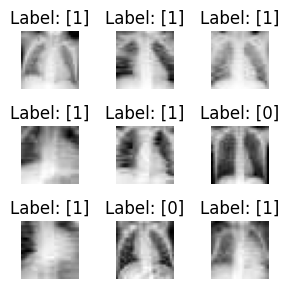

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(3,3))
for i, ax in enumerate(axes.flatten()):
    image, label = train_ds[i]        # unpack
    image_np = np.array(image)        # convert to NumPy array
    ax.imshow(image_np, cmap='gray')  # fixed
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### Prepare the data for Random Forest

In [28]:
import numpy as np

def flatten_ds(ds):
    images = []
    labels = []
    
    for item in ds:
        img, label = item       # unpack (PIL Image, int)
        img_np = np.array(img)  # convert to NumPy array
        img_flat = img_np.flatten()  # now flatten works
        images.append(img_flat)
        labels.append(label)
    
    images = np.array(images)
    labels = np.array(labels)
    
    return images, labels

X_train, y_train = flatten_ds(train_ds)
X_val,   y_val   = flatten_ds(val_ds)
X_test,  y_test  = flatten_ds(test_ds)

### 5 — Train a Random Forest Classifier
This trains 100 decision trees on random subsets of the flattened images

In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

### 6- Evaluate Performance

In [30]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8493589743589743
              precision    recall  f1-score   support

           0       0.94      0.64      0.76       234
           1       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624



### Step 7 — Confusion Matrix
The confusion matrix highlights real vs predicted counts:

[[149  85]
 [  9 381]]


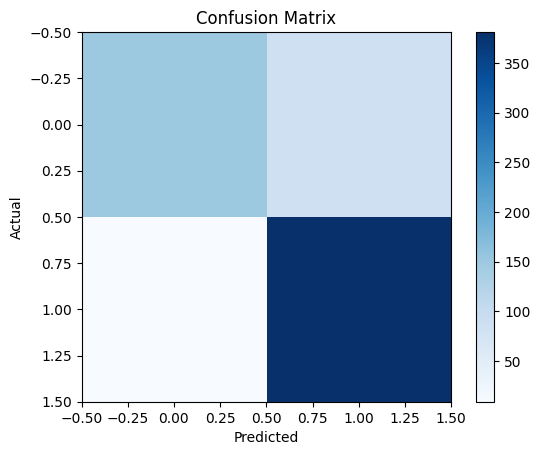

In [31]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Feature Importance

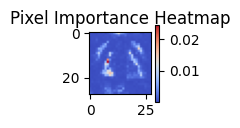

In [34]:
importances = rf.feature_importances_
importance_map = importances.reshape(28, 28) #collapse it back to the image

plt.figure(figsize=(1,1))
plt.imshow(importance_map, cmap='coolwarm')
plt.colorbar()
plt.title("Pixel Importance Heatmap")
plt.show()